In [8]:
import os
import numpy as np
import rasterio as rio
from rasterio.transform import from_origin
from whitebox import WhiteboxTools
from pathlib import Path
from nwtrace import ASI
import matplotlib.pyplot as plt

wbt = WhiteboxTools()

working_dir = Path("./dem/")
os.chdir(working_dir)

wbt.set_working_dir(path_str=os.path.abspath("./dem/"))

FileNotFoundError: [WinError 2] The system cannot find the file specified: 'dem'

In [2]:
with rio.open("flow_dir_d8.tif") as src:
    d8_arr = src.read(1)
    profile = src.profile

# A set representing outfall-inlet connections
inlet_connections = {
    "OF1": ["IN1"]
}

outfall_locations = {
    (8,1): "OF1"
}

inlet_locations = {
    "IN1": (2,2)
}

# set option for watershed type (Options: "OUTLET", "INLET", "OUTFALL")
watershed_type = "OUTFALL"

In [3]:
# create an inlet mask that indicates the locations of inlets in the dataset so they can be excluded from the list of seed cells
inlet_mask = np.zeros_like(d8_arr)

for r,c in inlet_locations.values():
    inlet_mask[r,c] = 1

In [4]:
sewershed = ASI(
    d8_flow_direction_raster = d8_arr,
    inlet_connections=inlet_connections,
    outfall_locations=outfall_locations,
    inlet_locations=inlet_locations,
    watershed_type=watershed_type
)

In [5]:
seeds = sewershed.get_seed_cells(d8_arr, inlet_mask)

seeds

[(0, 5), (6, 0), (9, 1), (9, 7)]

In [6]:
for r,c in seeds:
    sewershed.recursive_asi(r,c,f"{r}_{c}")

In [9]:
def display_raster(ras, cmap="viridis"):
    plt.imshow(ras, cmap=cmap)

    nrows = np.shape(ras)[0]
    ncols = np.shape(ras)[1]

    for r in range(nrows):
        for c in range(ncols):
            plt.text(c,r,f"{ras[r,c]:.0f}", ha="center", va="center", color="black")

    plt.gca().set_xticks(np.arange(-0.5, ncols, 1))
    plt.gca().set_yticks(np.arange(-0.5, nrows, 1))

    plt.gca().get_xaxis().set_ticklabels([])
    plt.gca().get_yaxis().set_ticklabels([])

    plt.grid(color="k", linewidth=0.5)
    plt.colorbar()

    plt.show()

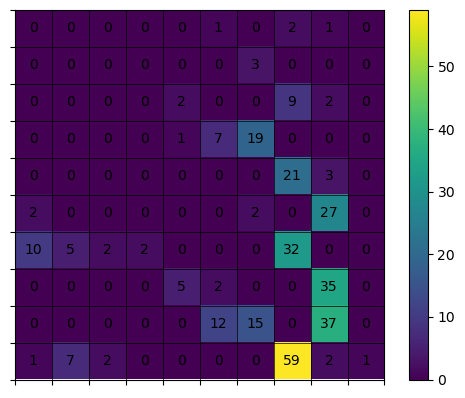

In [13]:
ras = sewershed.d8_accum

display_raster(ras)